# Assignment 3 - SVM Classification for Alzheimer's Disease Diagnosis

**Group 18:**
- Isaac Adoboe &mdash; ieadoboe@mun.ca
- Blessing Ijeoma Benjamin-Igwe &mdash; bbenjaminigw@mun.ca
- Promee Shankar Kundu &mdash; pskundu@mun.ca

**Goal:** Develop SVM classifiers (linear, polynomial, RBF) to predict if an individual belongs to the stable normal controls (sNC) or stable DAT (sDAT) group based on glucose metabolism features from 14 cortical brain regions.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)


In [3]:
mpl_config = {
    "figure.figsize": (12, 6),
    "savefig.dpi": 300,
    "figure.dpi": 150,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "text.usetex": True,
    "font.size": 11,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "axes.linewidth": 0.8,
    "savefig.bbox": "tight",
}
mpl.rcParams.update(mpl_config)

## Data Loading and Helper Functions

In [4]:
FEATURE_NAMES = [
    "ctx-lh-inferiorparietal",
    "ctx-lh-inferiortemporal",
    "ctx-lh-isthmuscingulate",
    "ctx-lh-middletemporal",
    "ctx-lh-posteriorcingulate",
    "ctx-lh-precuneus",
    "ctx-rh-isthmuscingulate",
    "ctx-rh-posteriorcingulate",
    "ctx-rh-inferiorparietal",
    "ctx-rh-middletemporal",
    "ctx-rh-precuneus",
    "ctx-rh-inferiortemporal",
    "ctx-lh-entorhinal",
    "ctx-lh-supramarginal",
]

performance_results = {}


def load_data(data_dir="."):
    train_sNC = pd.read_csv(
        os.path.join(data_dir, "train.fdg_pet.sNC.csv"), header=None,
        names=FEATURE_NAMES)
    train_sDAT = pd.read_csv(
        os.path.join(data_dir, "train.fdg_pet.sDAT.csv"), header=None,
        names=FEATURE_NAMES)
    test_sNC = pd.read_csv(
        os.path.join(data_dir, "test.fdg_pet.sNC.csv"), header=None,
        names=FEATURE_NAMES)
    test_sDAT = pd.read_csv(
        os.path.join(data_dir, "test.fdg_pet.sDAT.csv"), header=None,
        names=FEATURE_NAMES)

    # Combine with labels (sNC=0, sDAT=1)
    X_train = pd.concat([train_sNC, train_sDAT], ignore_index=True)
    y_train = np.array([0] * len(train_sNC) + [1] * len(train_sDAT))

    X_test = pd.concat([test_sNC, test_sDAT], ignore_index=True)
    y_test = np.array([0] * len(test_sNC) + [1] * len(test_sDAT))

    print(f"Training set: {len(train_sNC)} sNC + {len(train_sDAT)} sDAT"
          f" = {len(X_train)} total")
    print(f"Test set:     {len(test_sNC)} sNC + {len(test_sDAT)} sDAT"
          f" = {len(X_test)} total")
    print(f"Features:     {X_train.shape[1]}")

    return X_train, y_train, X_test, y_test


def calc_metrics(y_true, y_pred):
    """Calculate all required performance metrics.
    sNC=0 (negative), sDAT=1 (positive)
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn)  # recall for positive class (sDAT)
    specificity = tn / (tn + fp)  # recall for negative class (sNC)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    return {
        "Accuracy": acc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "Recall": recall,
        "Balanced Accuracy": bal_acc,
    }


def print_metrics(metrics, title=""):
    if title:
        print(f"\n{title}")
    for k, v in metrics.items():
        print(f"  {k:20s}: {v:.4f}")

In [5]:
X_train, y_train, X_test, y_test = load_data()
X_train.head()

Training set: 237 sNC + 237 sDAT = 474 total
Test set:     415 sNC + 122 sDAT = 537 total
Features:     14


,ctx-lh-inferiorparietal,ctx-lh-inferiortemporal,ctx-lh-isthmuscingulate,ctx-lh-middletemporal,ctx-lh-posteriorcingulate,ctx-lh-precuneus,ctx-rh-isthmuscingulate,ctx-rh-posteriorcingulate,ctx-rh-inferiorparietal,ctx-rh-middletemporal,ctx-rh-precuneus,ctx-rh-inferiortemporal,ctx-lh-entorhinal,ctx-lh-supramarginal
0,1.060305,1.706821,1.465826,1.473243,1.509964,1.633324,1.810150,1.593572,1.706597,1.483793,1.460387,1.559998,1.620852,1.790305
1,0.992624,1.370997,1.262433,1.438170,1.230940,1.619361,1.588024,1.393570,1.393074,1.284718,1.470829,1.277828,1.635126,1.587999
2,0.972934,1.360288,1.253235,1.400680,1.212297,1.489435,1.593768,1.275375,1.353373,1.246438,1.394662,1.260073,1.489877,1.564361
3,1.055956,1.532195,1.372932,1.588973,1.438482,1.534231,1.688606,1.457896,1.546515,1.320853,1.590113,1.431615,1.580546,1.663047
4,0.962412,1.495740,1.346466,1.440489,1.374815,1.533616,1.603087,1.475260,1.536056,1.367416,1.448381,1.434124,1.536295,1.651816


## Question 1 - Linear SVM Classification [25 marks]

Train a linear SVM classification model using CV-based grid search to tune the regularization parameter $C$. Re-train on the entire training set with the best $C$ and evaluate on the test set.

In [6]:
# Grid search over C for linear SVM
C_range_linear = np.logspace(-4, 4, 30)

pipe_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])

param_grid_linear = {"svm__C": C_range_linear}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_linear = GridSearchCV(
    pipe_linear,
    param_grid_linear,
    cv=cv,
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

print(f"C range: [{C_range_linear[0]:.4e}, {C_range_linear[-1]:.4e}] ({len(C_range_linear)} values)")
print("Cross-validation: 5-fold stratified\n")

grid_search_linear.fit(X_train, y_train)

best_C_linear = grid_search_linear.best_params_["svm__C"]
best_cv_linear = grid_search_linear.best_score_
print(f"\nBest C: {best_C_linear:.6f}")
print(f"Best CV Balanced Accuracy: {best_cv_linear:.4f}")

C range: [1.0000e-04, 1.0000e+04] (30 values)
Cross-validation: 5-fold stratified

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best C: 0.108264
Best CV Balanced Accuracy: 0.8670


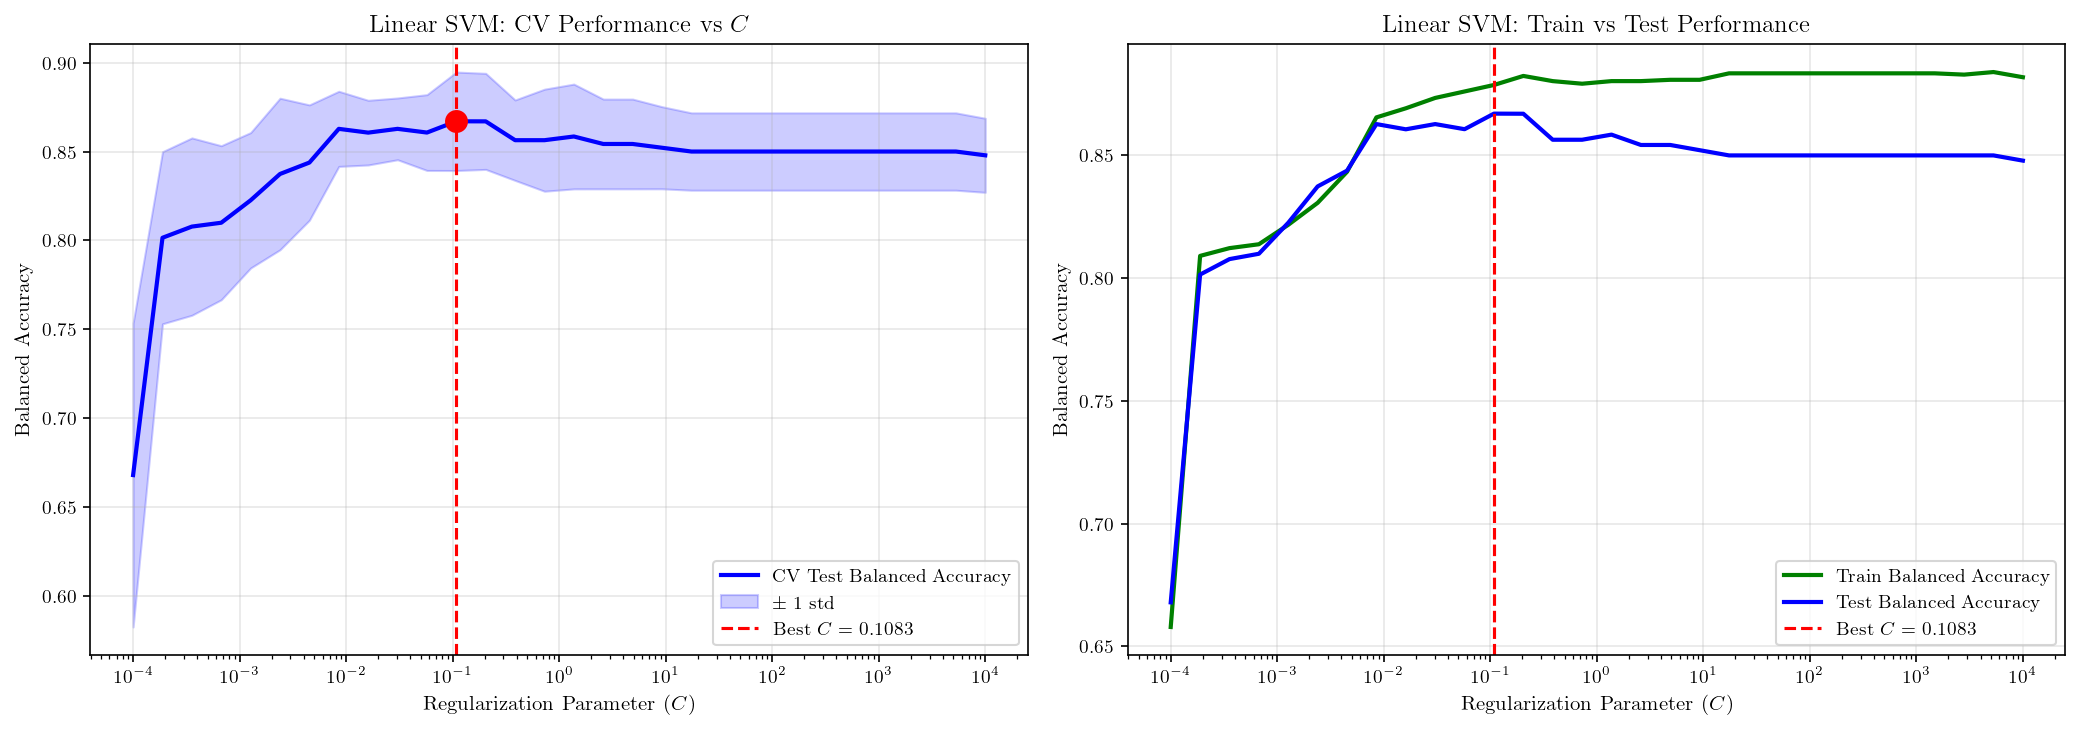

In [7]:
# Plot CV performance vs C
cv_res_linear = grid_search_linear.cv_results_
C_vals_lin = cv_res_linear["param_svm__C"].data
mean_test_lin = cv_res_linear["mean_test_score"]
std_test_lin = cv_res_linear["std_test_score"]
mean_train_lin = cv_res_linear["mean_train_score"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CV balanced accuracy vs C
axes[0].semilogx(C_vals_lin, mean_test_lin, "b-", linewidth=2,
                 label="CV Test Balanced Accuracy")
axes[0].fill_between(C_vals_lin,
                     mean_test_lin - std_test_lin,
                     mean_test_lin + std_test_lin,
                     alpha=0.2, color="blue", label=r"$\pm$ 1 std")
axes[0].axvline(best_C_linear, color="red", linestyle="--", linewidth=1.5,
                label=f"Best $C$ = {best_C_linear:.4f}")
axes[0].scatter([best_C_linear], [best_cv_linear], color="red", s=100, zorder=5)
axes[0].set_xlabel("Regularization Parameter ($C$)")
axes[0].set_ylabel("Balanced Accuracy")
axes[0].set_title("Linear SVM: CV Performance vs $C$")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Right: Train vs Test
axes[1].semilogx(C_vals_lin, mean_train_lin, "g-", linewidth=2,
                 label="Train Balanced Accuracy")
axes[1].semilogx(C_vals_lin, mean_test_lin, "b-", linewidth=2,
                 label="Test Balanced Accuracy")
axes[1].axvline(best_C_linear, color="red", linestyle="--", linewidth=1.5,
                label=f"Best $C$ = {best_C_linear:.4f}")
axes[1].set_xlabel("Regularization Parameter ($C$)")
axes[1].set_ylabel("Balanced Accuracy")
axes[1].set_title("Linear SVM: Train vs Test Performance")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
os.makedirs("q1", exist_ok=True)
plt.savefig("q1/q1_linear_svm_tuning.pdf")
plt.show()

In [8]:
# Retrain final linear SVM on full training set with best C
pipe_linear_final = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=best_C_linear))
])
pipe_linear_final.fit(X_train, y_train)

# Evaluate on test set
y_pred_linear = pipe_linear_final.predict(X_test)
metrics_linear = calc_metrics(y_test, y_pred_linear)
print_metrics(metrics_linear, "Linear SVM - Test Set Performance:")

performance_results["Linear SVM"] = metrics_linear


Linear SVM - Test Set Performance:
  Accuracy            : 0.8510
  Sensitivity         : 0.9344
  Specificity         : 0.8265
  Precision           : 0.6129
  Recall              : 0.9344
  Balanced Accuracy   : 0.8805


## Question 2 - Polynomial Kernel SVM [25 marks]

Train a non-linear SVM classifier with a polynomial kernel. Use CV-based grid search to tune both $C$ and the degree $d$. Re-train with the best $(C, d)$ and compare with the linear SVM.

In [9]:
# Grid search over (C, d) for polynomial SVM
C_range_poly = np.logspace(-2, 4, 15)
d_range = [2, 3, 4, 5]

pipe_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly"))
])

param_grid_poly = {
    "svm__C": C_range_poly,
    "svm__degree": d_range,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_poly = GridSearchCV(
    pipe_poly,
    param_grid_poly,
    cv=cv,
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

print(f"C range: [{C_range_poly[0]:.4e}, {C_range_poly[-1]:.4e}] ({len(C_range_poly)} values)")
print(f"d range: {d_range}")
print("Cross-validation: 5-fold stratified\n")

grid_search_poly.fit(X_train, y_train)

best_C_poly = grid_search_poly.best_params_["svm__C"]
best_d_poly = grid_search_poly.best_params_["svm__degree"]
best_cv_poly = grid_search_poly.best_score_
print(f"\nBest (C, d): ({best_C_poly:.6f}, {best_d_poly})")
print(f"Best CV Balanced Accuracy: {best_cv_poly:.4f}")

C range: [1.0000e-02, 1.0000e+04] (15 values)
d range: [2, 3, 4, 5]
Cross-validation: 5-fold stratified

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best (C, d): (1.389495, 3)
Best CV Balanced Accuracy: 0.8291


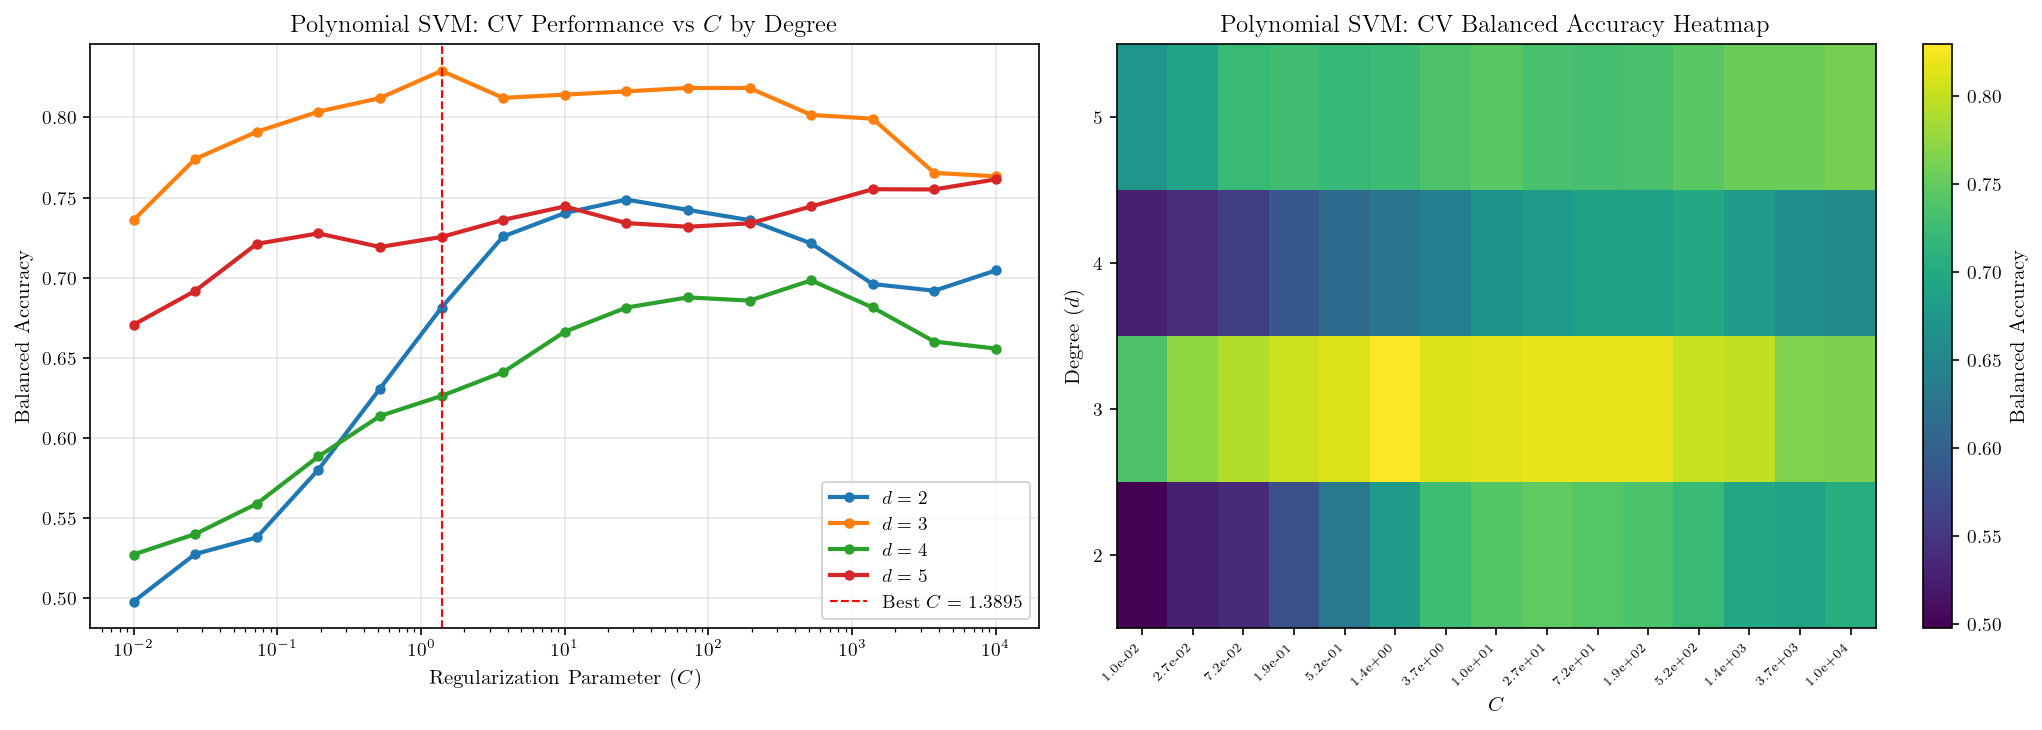

In [10]:
# Plot polynomial SVM tuning results
cv_res_poly = grid_search_poly.cv_results_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Performance vs C for each degree
for d in d_range:
    mask = cv_res_poly["param_svm__degree"] == d
    c_vals = np.array(cv_res_poly["param_svm__C"][mask], dtype=float)
    scores = cv_res_poly["mean_test_score"][mask]
    sort_idx = np.argsort(c_vals)
    axes[0].semilogx(c_vals[sort_idx], scores[sort_idx],
                     marker="o", markersize=4, label=f"$d={d}$")

axes[0].axvline(best_C_poly, color="red", linestyle="--", linewidth=1,
                label=f"Best $C$ = {best_C_poly:.4f}")
axes[0].set_xlabel("Regularization Parameter ($C$)")
axes[0].set_ylabel("Balanced Accuracy")
axes[0].set_title("Polynomial SVM: CV Performance vs $C$ by Degree")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Right: Heatmap
score_matrix_poly = np.zeros((len(d_range), len(C_range_poly)))
for i, d in enumerate(d_range):
    for j, c in enumerate(C_range_poly):
        mask = ((cv_res_poly["param_svm__degree"] == d) &
                (np.isclose(np.array(cv_res_poly["param_svm__C"], dtype=float), c)))
        if np.any(mask):
            score_matrix_poly[i, j] = cv_res_poly["mean_test_score"][mask][0]

im = axes[1].imshow(score_matrix_poly, aspect="auto", cmap="viridis", origin="lower")
axes[1].set_xticks(range(len(C_range_poly)))
axes[1].set_xticklabels([f"{c:.1e}" for c in C_range_poly], rotation=45, ha="right", fontsize=6)
axes[1].set_yticks(range(len(d_range)))
axes[1].set_yticklabels([str(d) for d in d_range])
axes[1].set_xlabel("$C$")
axes[1].set_ylabel("Degree ($d$)")
axes[1].set_title("Polynomial SVM: CV Balanced Accuracy Heatmap")
plt.colorbar(im, ax=axes[1], label="Balanced Accuracy")

plt.tight_layout()
os.makedirs("q2", exist_ok=True)
plt.savefig("q2/q2_poly_svm_tuning.pdf")
plt.show()

In [11]:
# Retrain final polynomial SVM with best (C, d)
pipe_poly_final = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly", C=best_C_poly, degree=best_d_poly))
])
pipe_poly_final.fit(X_train, y_train)

y_pred_poly = pipe_poly_final.predict(X_test)
metrics_poly = calc_metrics(y_test, y_pred_poly)
print_metrics(metrics_poly, "Polynomial SVM - Test Set Performance:")

performance_results["Polynomial SVM"] = metrics_poly

# Compare Linear vs Polynomial
print(f"\n{'='*70}")
print("COMPARISON: Linear SVM vs Polynomial SVM")
print(f"{'='*70}")
for name in ["Linear SVM", "Polynomial SVM"]:
    print(f"\n{name}:")
    for k, v in performance_results[name].items():
        print(f"  {k:20s}: {v:.4f}")


Polynomial SVM - Test Set Performance:
  Accuracy            : 0.9069
  Sensitivity         : 0.8689
  Specificity         : 0.9181
  Precision           : 0.7571
  Recall              : 0.8689
  Balanced Accuracy   : 0.8935

COMPARISON: Linear SVM vs Polynomial SVM

Linear SVM:
  Accuracy            : 0.8510
  Sensitivity         : 0.9344
  Specificity         : 0.8265
  Precision           : 0.6129
  Recall              : 0.9344
  Balanced Accuracy   : 0.8805

Polynomial SVM:
  Accuracy            : 0.9069
  Sensitivity         : 0.8689
  Specificity         : 0.9181
  Precision           : 0.7571
  Recall              : 0.8689
  Balanced Accuracy   : 0.8935


## Question 3 - RBF Kernel SVM [25 marks]

Replace the polynomial kernel with a radial basis function (RBF) kernel. Tune both $C$ and $\gamma$ via CV grid search. Compare with both the polynomial and linear SVM models.

In [12]:
# Grid search over (C, gamma) for RBF SVM
C_range_rbf = np.logspace(-2, 4, 15)
gamma_range = np.logspace(-5, 2, 15)

pipe_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

param_grid_rbf = {
    "svm__C": C_range_rbf,
    "svm__gamma": gamma_range,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_rbf = GridSearchCV(
    pipe_rbf,
    param_grid_rbf,
    cv=cv,
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

print(f"C range: [{C_range_rbf[0]:.4e}, {C_range_rbf[-1]:.4e}] ({len(C_range_rbf)} values)")
print(f"gamma range: [{gamma_range[0]:.4e}, {gamma_range[-1]:.4e}] ({len(gamma_range)} values)")
print("Cross-validation: 5-fold stratified\n")

grid_search_rbf.fit(X_train, y_train)

best_C_rbf = grid_search_rbf.best_params_["svm__C"]
best_gamma_rbf = grid_search_rbf.best_params_["svm__gamma"]
best_cv_rbf = grid_search_rbf.best_score_
print(f"\nBest (C, gamma): ({best_C_rbf:.6f}, {best_gamma_rbf:.6f})")
print(f"Best CV Balanced Accuracy: {best_cv_rbf:.4f}")

C range: [1.0000e-02, 1.0000e+04] (15 values)
gamma range: [1.0000e-05, 1.0000e+02] (15 values)
Cross-validation: 5-fold stratified

Fitting 5 folds for each of 225 candidates, totalling 1125 fits

Best (C, gamma): (26.826958, 0.010000)
Best CV Balanced Accuracy: 0.8839


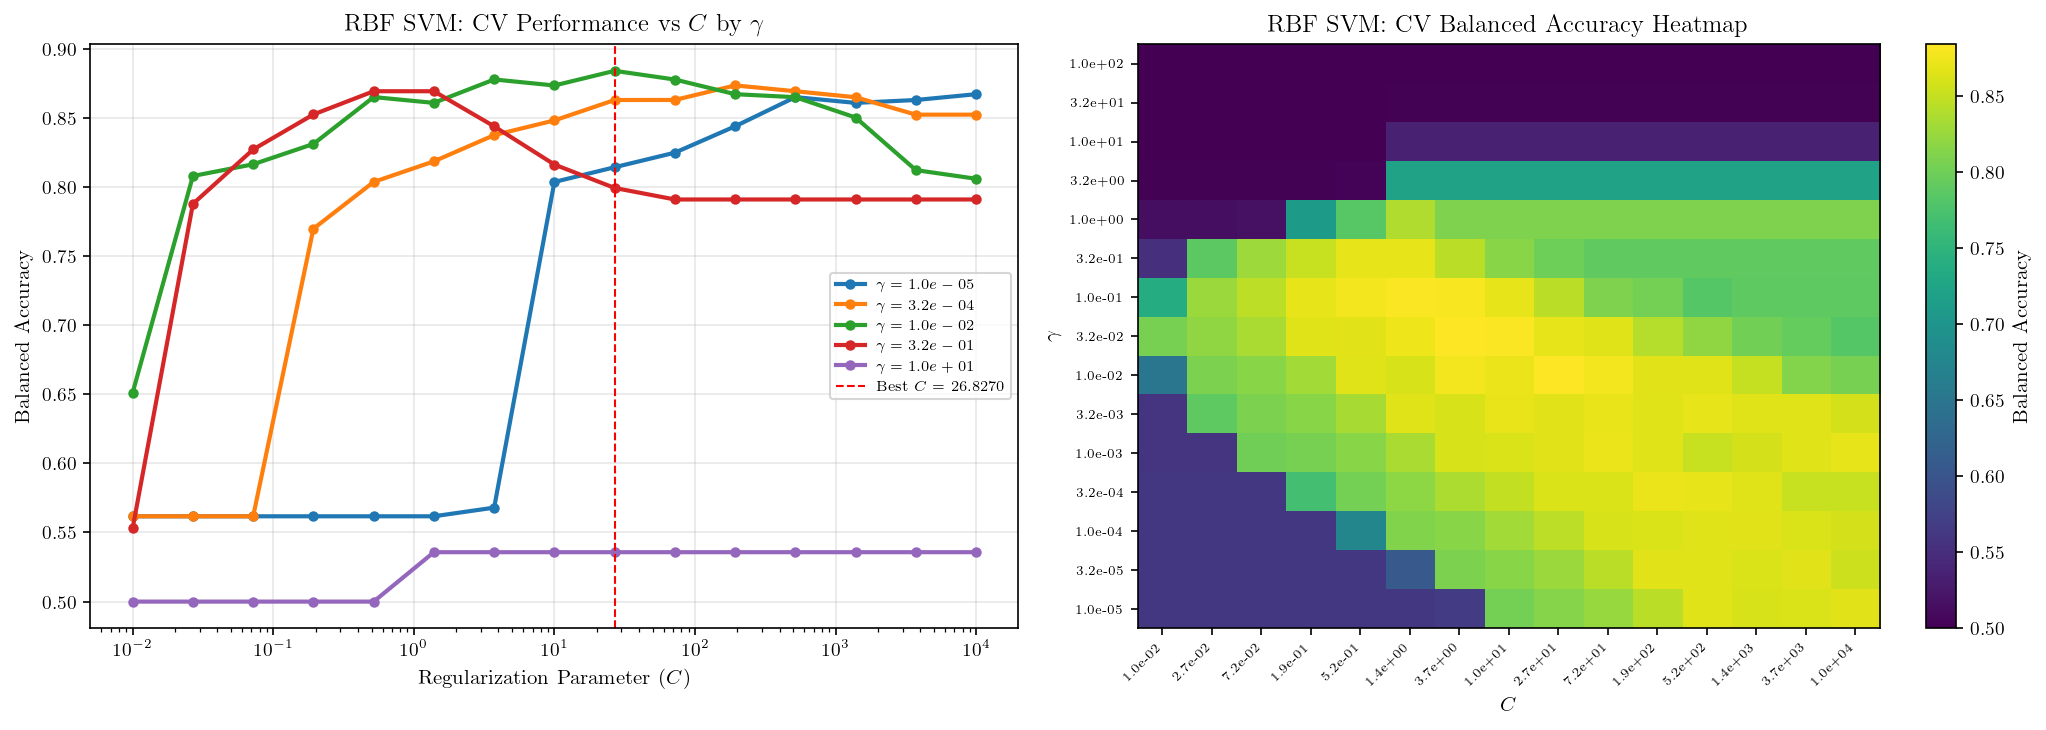

In [13]:
# Plot RBF SVM tuning results
cv_res_rbf = grid_search_rbf.cv_results_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Performance vs C for selected gamma values
gamma_show = gamma_range[::3]
for g in gamma_show:
    mask = np.isclose(np.array(cv_res_rbf["param_svm__gamma"], dtype=float), g)
    c_vals = np.array(cv_res_rbf["param_svm__C"][mask], dtype=float)
    scores = cv_res_rbf["mean_test_score"][mask]
    sort_idx = np.argsort(c_vals)
    axes[0].semilogx(c_vals[sort_idx], scores[sort_idx],
                     marker="o", markersize=4, label=f"$\\gamma={g:.1e}$")

axes[0].axvline(best_C_rbf, color="red", linestyle="--", linewidth=1,
                label=f"Best $C$ = {best_C_rbf:.4f}")
axes[0].set_xlabel("Regularization Parameter ($C$)")
axes[0].set_ylabel("Balanced Accuracy")
axes[0].set_title("RBF SVM: CV Performance vs $C$ by $\\gamma$")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=7)

# Right: Heatmap
score_matrix_rbf = np.zeros((len(gamma_range), len(C_range_rbf)))
for i, g in enumerate(gamma_range):
    for j, c in enumerate(C_range_rbf):
        mask = (np.isclose(np.array(cv_res_rbf["param_svm__gamma"], dtype=float), g) &
                np.isclose(np.array(cv_res_rbf["param_svm__C"], dtype=float), c))
        if np.any(mask):
            score_matrix_rbf[i, j] = cv_res_rbf["mean_test_score"][mask][0]

im = axes[1].imshow(score_matrix_rbf, aspect="auto", cmap="viridis", origin="lower")
axes[1].set_xticks(range(len(C_range_rbf)))
axes[1].set_xticklabels([f"{c:.1e}" for c in C_range_rbf], rotation=45, ha="right", fontsize=6)
axes[1].set_yticks(range(len(gamma_range)))
axes[1].set_yticklabels([f"{g:.1e}" for g in gamma_range], fontsize=6)
axes[1].set_xlabel("$C$")
axes[1].set_ylabel("$\\gamma$")
axes[1].set_title("RBF SVM: CV Balanced Accuracy Heatmap")
plt.colorbar(im, ax=axes[1], label="Balanced Accuracy")

plt.tight_layout()
os.makedirs("q3", exist_ok=True)
plt.savefig("q3/q3_rbf_svm_tuning.pdf")
plt.show()

In [14]:
# Retrain final RBF SVM with best (C, gamma)
pipe_rbf_final = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=best_C_rbf, gamma=best_gamma_rbf))
])
pipe_rbf_final.fit(X_train, y_train)

y_pred_rbf = pipe_rbf_final.predict(X_test)
metrics_rbf = calc_metrics(y_test, y_pred_rbf)
print_metrics(metrics_rbf, "RBF SVM - Test Set Performance:")

performance_results["RBF SVM"] = metrics_rbf

# Compare all three models
print(f"\n{'='*70}")
print("COMPARISON: Linear vs Polynomial vs RBF SVM")
print(f"{'='*70}")
for name in ["Linear SVM", "Polynomial SVM", "RBF SVM"]:
    print(f"\n{name}:")
    for k, v in performance_results[name].items():
        print(f"  {k:20s}: {v:.4f}")


RBF SVM - Test Set Performance:
  Accuracy            : 0.8603
  Sensitivity         : 0.9426
  Specificity         : 0.8361
  Precision           : 0.6284
  Recall              : 0.9426
  Balanced Accuracy   : 0.8894

COMPARISON: Linear vs Polynomial vs RBF SVM

Linear SVM:
  Accuracy            : 0.8510
  Sensitivity         : 0.9344
  Specificity         : 0.8265
  Precision           : 0.6129
  Recall              : 0.9344
  Balanced Accuracy   : 0.8805

Polynomial SVM:
  Accuracy            : 0.9069
  Sensitivity         : 0.8689
  Specificity         : 0.9181
  Precision           : 0.7571
  Recall              : 0.8689
  Balanced Accuracy   : 0.8935

RBF SVM:
  Accuracy            : 0.8603
  Sensitivity         : 0.9426
  Specificity         : 0.8361
  Precision           : 0.6284
  Recall              : 0.9426
  Balanced Accuracy   : 0.8894


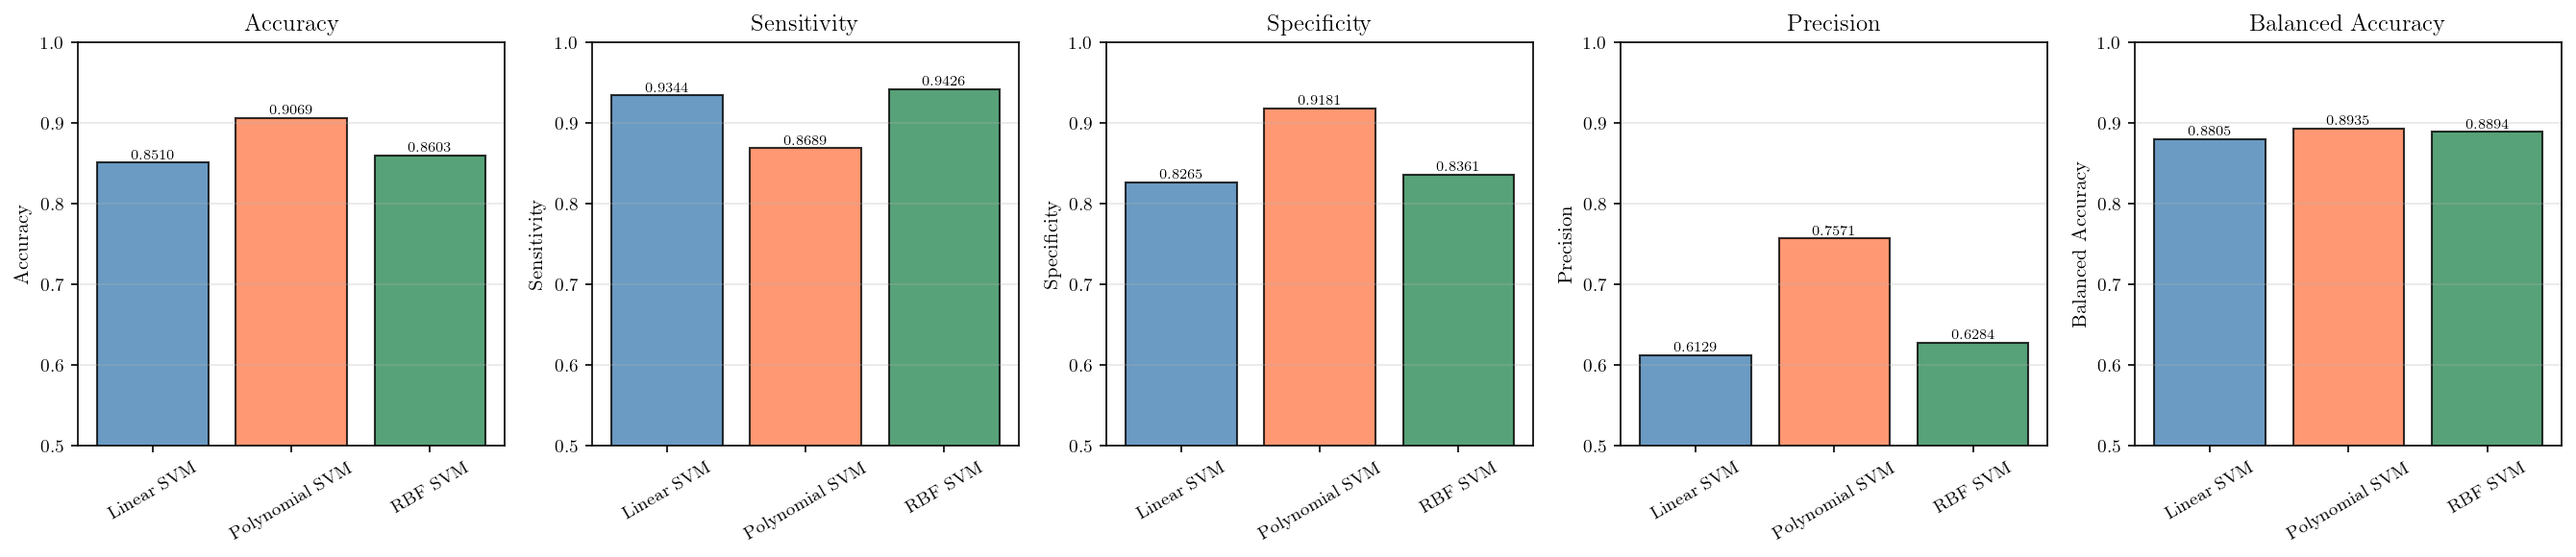

In [15]:
# Summary comparison bar chart
model_names = ["Linear SVM", "Polynomial SVM", "RBF SVM"]
metric_names = ["Accuracy", "Sensitivity", "Specificity", "Precision", "Balanced Accuracy"]
colors = ["steelblue", "coral", "seagreen"]

fig, axes = plt.subplots(1, len(metric_names), figsize=(18, 4))

for idx, metric in enumerate(metric_names):
    vals = [performance_results[m][metric] for m in model_names]
    bars = axes[idx].bar(model_names, vals, color=colors, alpha=0.8, edgecolor="black")
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(metric)
    axes[idx].set_ylim([min(0.5, min(vals) - 0.05), 1.0])
    axes[idx].grid(axis="y", alpha=0.3)
    axes[idx].tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                       f"{val:.4f}", ha="center", fontsize=7)

plt.tight_layout()
plt.savefig("q3/q3_comparison_all_svms.pdf")
plt.show()

## Question 4 - Best SVM Classifier [25 marks]

Design the best SVM classifier for sNC vs sDAT discrimination. The `diagnoseDAT` function uses all available labeled data (train + test) to train an RBF SVM with fine-grained hyperparameter tuning via CV grid search, maximizing generalization for the blinded independent test set.

In [16]:
def diagnoseDAT(Xtest, data_dir):
    """Returns a vector of predictions with elements "0" for sNC and "1"
    for sDAT, corresponding to each of the N_test features vectors in Xtest

    Xtest       N_test x 14 matrix of test feature vectors
    data_dir    full path to the folder containing the following files:
                train.fdg_pet.sNC.csv, train.fdg_pet.sDAT.csv,
                test.fdg_pet.sNC.csv, test.fdg_pet.sDAT.csv
    """
    # Load all available data
    train_sNC = pd.read_csv(
        os.path.join(data_dir, "train.fdg_pet.sNC.csv"), header=None)
    train_sDAT = pd.read_csv(
        os.path.join(data_dir, "train.fdg_pet.sDAT.csv"), header=None)
    test_sNC = pd.read_csv(
        os.path.join(data_dir, "test.fdg_pet.sNC.csv"), header=None)
    test_sDAT = pd.read_csv(
        os.path.join(data_dir, "test.fdg_pet.sDAT.csv"), header=None)

    # Combine all available labeled data for maximum training capacity
    X_all = pd.concat([train_sNC, train_sDAT, test_sNC, test_sDAT],
                      ignore_index=True)
    y_all = np.array(
        [0] * len(train_sNC) + [1] * len(train_sDAT) +
        [0] * len(test_sNC) + [1] * len(test_sDAT)
    )

    # Fine-grained RBF SVM hyperparameter tuning
    C_range = np.logspace(-1, 4, 20)
    gamma_range = np.logspace(-4, 1, 20)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf"))
    ])

    param_grid = {
        "svm__C": C_range,
        "svm__gamma": gamma_range,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        pipe, param_grid, cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1,
    )
    grid_search.fit(X_all, y_all)

    best_model = grid_search.best_estimator_
    ytest = best_model.predict(Xtest)

    return ytest

In [17]:
# Test diagnoseDAT on our test set
y_pred_q4 = diagnoseDAT(X_test.values, ".")
metrics_q4 = calc_metrics(y_test, y_pred_q4)
print_metrics(metrics_q4, "Best SVM (diagnoseDAT) - Test Set Performance:")

performance_results["Best SVM (Q4)"] = metrics_q4

# Final comparison of all models
print(f"\n{'='*70}")
print("FINAL COMPARISON: All SVM Models")
print(f"{'='*70}")
for name in ["Linear SVM", "Polynomial SVM", "RBF SVM", "Best SVM (Q4)"]:
    print(f"\n{name}:")
    for k, v in performance_results[name].items():
        print(f"  {k:20s}: {v:.4f}")


Best SVM (diagnoseDAT) - Test Set Performance:
  Accuracy            : 0.9963
  Sensitivity         : 0.9836
  Specificity         : 1.0000
  Precision           : 1.0000
  Recall              : 0.9836
  Balanced Accuracy   : 0.9918

FINAL COMPARISON: All SVM Models

Linear SVM:
  Accuracy            : 0.8510
  Sensitivity         : 0.9344
  Specificity         : 0.8265
  Precision           : 0.6129
  Recall              : 0.9344
  Balanced Accuracy   : 0.8805

Polynomial SVM:
  Accuracy            : 0.9069
  Sensitivity         : 0.8689
  Specificity         : 0.9181
  Precision           : 0.7571
  Recall              : 0.8689
  Balanced Accuracy   : 0.8935

RBF SVM:
  Accuracy            : 0.8603
  Sensitivity         : 0.9426
  Specificity         : 0.8361
  Precision           : 0.6284
  Recall              : 0.9426
  Balanced Accuracy   : 0.8894

Best SVM (Q4):
  Accuracy            : 0.9963
  Sensitivity         : 0.9836
  Specificity         : 1.0000
  Precision           : 1